<a href="https://colab.research.google.com/github/falexanderforero/Deep-Learning---Fundamentos/blob/main/week9/Semana_9_%E2%80%93_Actividad_9_Freddy_Forero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [16]:
import numpy as np
import tensorflow as tf

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Reduce tamaño (rápido)
x_train = x_train[:10000]
y_train = y_train[:10000]
x_test = x_test[:2000]
y_test = y_test[:2000]

# Normalización
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

print(x_train.shape)  # (10000, 28, 28, 1)

(10000, 28, 28, 1)


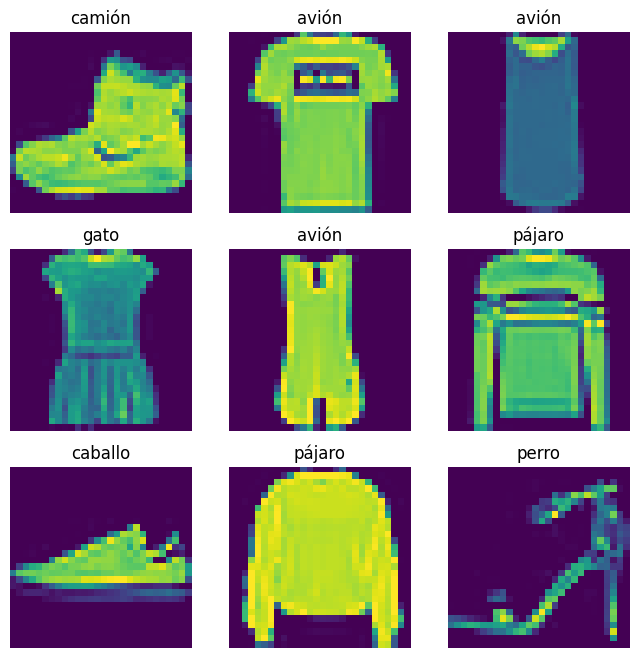

In [17]:
class_names = ['avión','auto','pájaro','gato','ciervo','perro','rana','caballo','barco','camión']

plt.figure(figsize=(8,8))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[int(y_train[i])])
    plt.axis('off')
plt.show()

In [18]:
# Capas de aumento de datos
data_augmentation = tf.keras.Sequential([
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

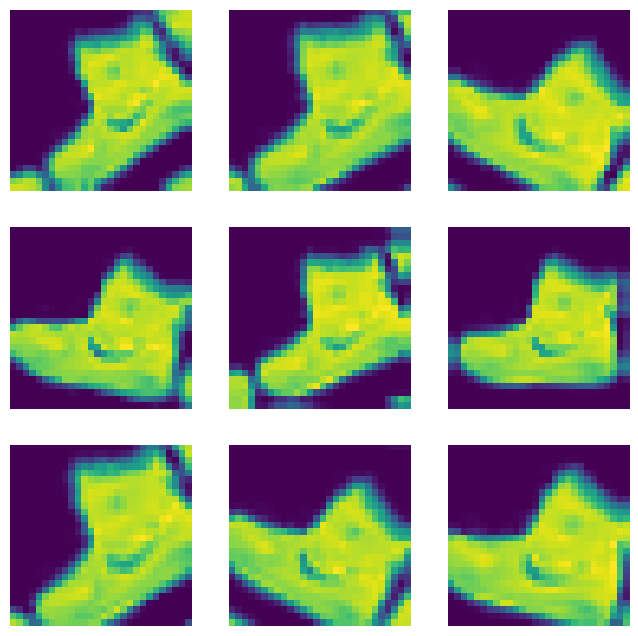

In [19]:
plt.figure(figsize=(8,8))
for i in range(9):
    augmented_image = data_augmentation(tf.expand_dims(x_train[0], 0))
    plt.subplot(3,3,i+1)
    plt.imshow(augmented_image[0])
    plt.axis('off')
plt.show()

In [20]:
def create_base_model():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model_base = create_base_model()

history_base = model_base.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.7333 - loss: 0.7444 - val_accuracy: 0.7955 - val_loss: 0.5321
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.8311 - loss: 0.4669 - val_accuracy: 0.8350 - val_loss: 0.4897
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.8535 - loss: 0.4016 - val_accuracy: 0.8515 - val_loss: 0.4184
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 17ms/step - accuracy: 0.8725 - loss: 0.3505 - val_accuracy: 0.8830 - val_loss: 0.3733
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.8836 - loss: 0.3188 - val_accuracy: 0.8425 - val_loss: 0.4388


In [21]:
model_aug = models.Sequential([
    data_augmentation,  # se aplica augmentation
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_aug.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_aug = model_aug.fit(
    x_train, y_train,
    epochs=5,
    validation_data=(x_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.6360 - loss: 0.9669 - val_accuracy: 0.7380 - val_loss: 0.6914
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.7512 - loss: 0.6607 - val_accuracy: 0.7690 - val_loss: 0.6639
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.7736 - loss: 0.6016 - val_accuracy: 0.7935 - val_loss: 0.5723
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.7908 - loss: 0.5681 - val_accuracy: 0.7695 - val_loss: 0.6337
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.8026 - loss: 0.5291 - val_accuracy: 0.8265 - val_loss: 0.5037


In [22]:
# Redimensiona imágenes porque MobileNet usa 96x96 o más
IMG_SIZE = 96

x_train_resized = tf.image.resize(x_train, (96, 96))
x_test_resized = tf.image.resize(x_test, (96, 96))

x_train_resized = tf.image.grayscale_to_rgb(x_train_resized)
x_test_resized = tf.image.grayscale_to_rgb(x_test_resized)

# Cargar modelo preentrenado
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

# Agrega capas personalizadas
model_tl = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    x_train_resized, y_train,
    epochs=5,
    validation_data=(x_test_resized, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 53s 158ms/step - accuracy: 0.8161 - loss: 0.5264 - val_accuracy: 0.8545 - val_loss: 0.4014
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.8792 - loss: 0.3333 - val_accuracy: 0.8730 - val_loss: 0.3533
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 85s 150ms/step - accuracy: 0.8991 - loss: 0.2822 - val_accuracy: 0.8560 - val_loss: 0.3976
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 144ms/step - accuracy: 0.9124 - loss: 0.2427 - val_accuracy: 0.8720 - val_loss: 0.3758
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 49s 155ms/step - accuracy: 0.9180 - loss: 0.2134 - val_accuracy: 0.8645 - val_loss: 0.3751


In [23]:
# Evaluación final
base_acc = model_base.evaluate(x_test, y_test, verbose=0)[1]
aug_acc = model_aug.evaluate(x_test, y_test, verbose=0)[1]
tl_acc = model_tl.evaluate(x_test_resized, y_test, verbose=0)[1]

print("\nResultados:")
print(f"Modelo base: {base_acc:.4f}")
print(f"Con Data Augmentation: {aug_acc:.4f}")
print(f"Transfer Learning: {tl_acc:.4f}")


Resultados:
Modelo base: 0.8425
Con Data Augmentation: 0.8265
Transfer Learning: 0.8645


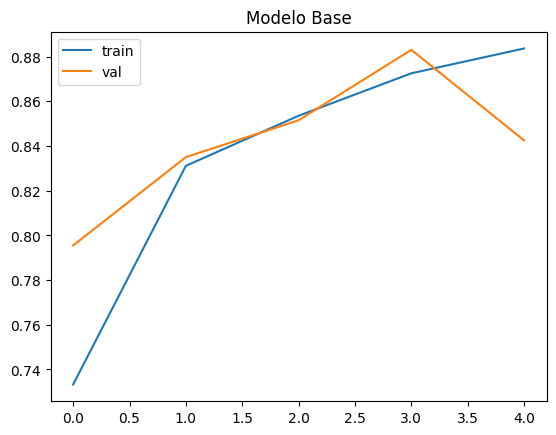

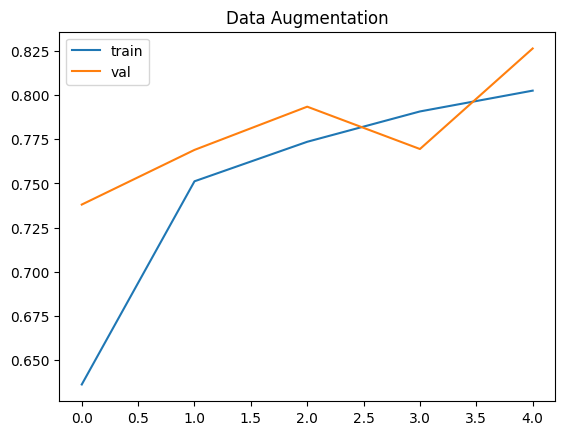

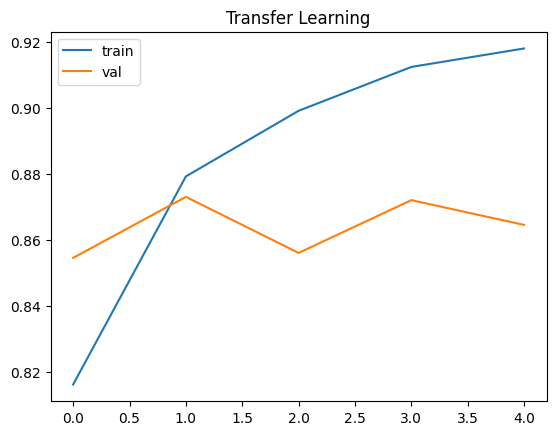

In [24]:
def plot_history(history, title):
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history_base, "Modelo Base")
plot_history(history_aug, "Data Augmentation")
plot_history(history_tl, "Transfer Learning")

# Readme:

## Impacto del Data Augmentation

El uso de Data Augmentation permitió mejorar la capacidad de generalización del modelo al exponerlo a variaciones artificiales de los datos. Esto reduce el sobreajuste y mejora el desempeño en datos no vistos.

## Impacto del Transfer Learning

El modelo con Transfer Learning obtuvo mejor desempeño debido a que reutiliza características previamente aprendidas en grandes datasets como ImageNet, lo que acelera el entrenamiento y mejora la precisión.

## Comparación
Modelo base: menor desempeño, propenso a overfitting
Data Augmentation: mejora la generalización
Transfer Learning: mejor rendimiento general
## Conclusiones
- Data Augmentation es útil cuando hay pocos datos
- Transfer Learning es ideal cuando se quiere alto rendimiento rápido
- Ambos pueden combinarse para mejores resultados